In [19]:
import pandas as pd
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [20]:
df=pd.read_csv('Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [21]:
x=df.drop(columns='Performance Index')
y=df['Performance Index']

In [22]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

<Axes: >

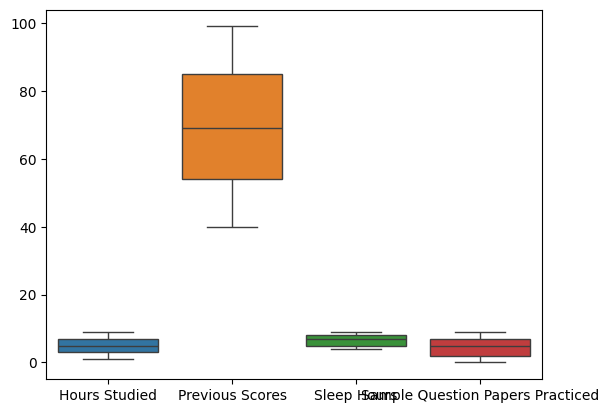

In [23]:
sns.boxplot(x[num_cols])

as we can see there is no outliers present in this data . so we can use normalization technique for scaling .

 i.e MinMAX Scaling

In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=42)

In [44]:
xtest

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
6252,5,69,No,8,2
4684,2,46,Yes,4,8
1731,7,56,Yes,7,5
4742,6,42,Yes,8,5
4521,7,53,No,4,6
...,...,...,...,...,...
6412,2,70,No,7,3
8285,4,79,No,9,3
7853,2,40,Yes,7,2
1095,3,83,No,7,5


In [39]:
xtrain

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_0,Extracurricular Activities_1
9254,0.500,0.152542,0,0.6,0.555556,1.0,0.0
1561,0.125,0.135593,1,0.6,0.666667,0.0,1.0
1670,0.125,0.694915,0,0.6,0.222222,1.0,0.0
6087,0.125,0.101695,0,0.4,0.111111,1.0,0.0
6669,0.875,0.118644,0,1.0,0.000000,1.0,0.0
...,...,...,...,...,...,...,...
5734,0.875,0.169492,1,0.4,0.666667,0.0,1.0
5191,0.375,0.474576,0,1.0,0.333333,1.0,0.0
5390,1.000,0.135593,0,0.6,0.666667,1.0,0.0
860,0.000,0.118644,0,1.0,0.000000,1.0,0.0


In [25]:
scaling = MinMaxScaler()
xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])

In [26]:
df.drop(columns='Extracurricular Activities').corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


Target = Performance Index - This is what you want to predict

Previous Scores vs Performance Index = 0.915 → Very strong positive correlation. Past scores are the best predictor.

Hours Studied vs Performance Index = 0.374 → Moderate positive correlation. More study hours = better performance.

Sleep Hours = 0.048 → Almost no linear relationship with performance. Very weak.

Sample Question Papers Practiced = 0.043 → Almost no linear relationship. Very weak.

No multicollinearity issue - Features aren't strongly related to each other. All inter-feature correlations are ∼0. All values < 0.02. Good for linear regression.

You dropped Extracurricular Activities - Probably because it was text/categorical. Correct move for .corr()

Can we use Linear Regression? Yes

Reason 1: Target Performance Index is numeric/continuous

Reason 2: Strong linear relationship exists → Previous Scores corr = 0.91

Reason 3: No multicollinearity → Features don't overlap with each other

Reason 4: Low correlation features won't break model → Model gives them ∼0 weight

Expected result: R² score will be very high, ∼0.9+, because one feature alone explains 91% relation

In [27]:
#Having 1 strong feature is enough for Linear Regression to work well

In [28]:
xtrain[obj_cols].nunique()

Extracurricular Activities    2
dtype: int64

Only 2 options like Yes/No? → LabelEncoder: Yes=1, No=0. Done.

3-10 options with no order like Dog/Cat/Bird? → OneHotEncoder: Makes 3 new columns. 

Has natural order like Low/Medium/High? → OrdinalEncoder: Low=0, Medium=1, High=2.

Too many options like 50 cities? → TargetEncoder: Replace city with avg performance of that city.

In [29]:
#as there is less unique value , we can use either label or one hot encoder

In [30]:
label_encoder=LabelEncoder()
#train[obj_cols]=label_encoder.fit_transform(xtrain[obj_cols])
#ValueError :Columns must be same as the key

the above code is error because LabelEncoder can only handle 1 column at a time, i.e. 1D data. But xtrain[obj_cols] is giving it multiple columns at once, i.e. 2D data. So sklearn throws that error: "Hey, I expected 1D data like a single column, you gave me a full DataFrame.

In [31]:
xtrain['Extracurricular Activities']=label_encoder.fit_transform(xtrain['Extracurricular Activities'])

NOW LETS TRY WITH ONE HOT ENCODER

In [32]:
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
values=encoder.fit_transform(xtrain[obj_cols])
cols=encoder.get_feature_names_out()

In [46]:
xtrain[cols]=values
xtrain.drop(columns=['Extracurricular Activities'],inplace=True)


In [35]:
num_cols

Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced'],
      dtype='object')

TRANSFORM XTEST

In [47]:
xtest[num_cols]=scaling.transform(xtest[num_cols])
xtest_values = encoder.transform(xtest[obj_cols])

In [48]:

xtest[cols]=xtest_values
xtest.drop(columns=['Extracurricular Activities'],inplace=True)

In [52]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(xtrain,ytrain)
model.score(xtrain,ytrain)


0.9886898790682355

In [53]:
model.score(xtest,ytest)

-21.69574827878798